<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112-/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-900711646.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='gray')
/tmp/ipython-input-900711646.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_equalized.ravel(), 256, [0, 256], color='gray')


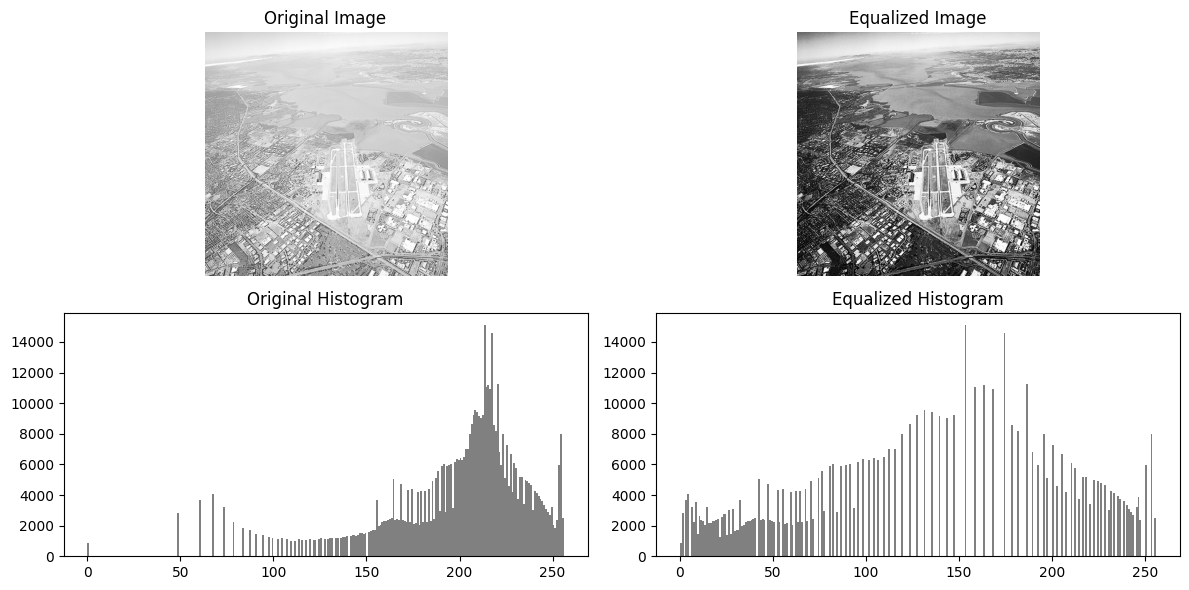

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


image_path = '/Assignment 01/runway.png'


# Read grayscale image
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Safety check
if img is None:
    raise FileNotFoundError("Image not found. Check the image path and filename.")


# Compute histogram
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Compute cumulative distribution function (CDF)
cdf = hist.cumsum()
cdf_normalized = cdf * 255 / cdf[-1]

# Apply equalization using linear interpolation
img_equalized = np.interp(img.flatten(), bins[:-1], cdf_normalized).reshape(img.shape).astype('uint8')

# -------------------------------
# Display images and histograms
# -------------------------------
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Equalized image
plt.subplot(2, 2, 2)
plt.imshow(img_equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# Histogram of original image
plt.subplot(2, 2, 3)
plt.hist(img.ravel(), 256, [0, 256], color='gray')
plt.title('Original Histogram')

# Histogram of equalized image
plt.subplot(2, 2, 4)
plt.hist(img_equalized.ravel(), 256, [0, 256], color='gray')
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()
